# 🏭 Feature Factory - auto-build a reusable sklearn ColumnTransformer

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/ml-engineering-toolkit/feature-factory/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=ml-engineering-toolkit/feature-factory/demo.ipynb)

> **Pain:** every new ML project you rewrite the same impute / scale / one-hot boilerplate, get the column lists slightly wrong, and leak test statistics into training.

**Feature Factory** inspects a DataFrame, classifies each column into a role, and assembles a fitted `ColumnTransformer` plus the expanded feature names - in one call, with no leakage (all stats learned on `fit`, replayed on `transform`).

**This notebook covers:**
1. A deliberately messy mixed-type table
2. Inferring a feature plan (the rules)
3. Building & fitting the transformer
4. Transforming *unseen* data safely
5. A visual of the raw → engineered column expansion

## Step 1 - a messy table, like every real one
Numerics with gaps, low-card categories, a boolean, a datetime, an id column, and a high-cardinality free-text column. A hand-written pipeline has to decide what to do with each - that's the work we want to automate.

In [1]:
from __future__ import annotations
from typing import List, Optional
import pandas as pd
import numpy as np
from factory import make_sample_data, infer_plan, fit_transform, build_transformer

df = make_sample_data()
print(f'{len(df)} rows x {df.shape[1]} columns')
print('missing values per column:')
print(df.isna().sum()[df.isna().sum() > 0])
df.head()

200 rows x 9 columns
missing values per column:
age     20
plan    16
dtype: int64


,customer_id,age,monthly_spend,plan,region,is_active,signup_date,notes,churned
0,C00000,77.0,122.64,free,EU,False,2024-05-23,ticket-57401,1
1,C00001,NaN,15.65,team,EU,True,2024-07-01,ticket-74110,1
2,C00002,47.0,73.78,enterprise,NA,False,2025-04-25,ticket-34988,0
3,C00003,50.0,52.38,pro,NA,True,2024-06-18,ticket-59540,0
4,C00004,50.0,133.43,enterprise,APAC,True,2024-02-18,ticket-83545,0


## Step 2 - infer the feature plan
`infer_plan` classifies each column by dtype + cardinality:

| Role | Rule | Treatment |
|------|------|-----------|
| `numeric` | numeric dtype | median impute + standardize |
| `categorical` | low-card object | mode impute + one-hot |
| `binary` | 2 unique values | one-hot, single reference column |
| `datetime` | datetime dtype | expand to year/month/day/dow/hour |
| `drop` | id-like, high-card, or target | excluded |

It's a plan, not a black box - inspect it, and override any role before building.

In [2]:
plan = infer_plan(df, target='churned')
plan_df = pd.DataFrame(
    [(p.column, p.role, p.reason) for p in plan.plans],
    columns=['column', 'role', 'why'],
)
plan_df

,column,role,why
0,customer_id,drop,id-like (200/200 unique)
1,age,numeric,numeric dtype
2,monthly_spend,numeric,numeric dtype
3,plan,categorical,4 categories
4,region,categorical,4 categories
5,is_active,binary,2 unique values
6,signup_date,datetime,datetime dtype
7,notes,drop,id-like (200/200 unique)
8,churned,drop,target column


## Step 3 - build & fit the ColumnTransformer
One call returns the model-ready matrix **and** the fitted transformer. Note the column count grows (one-hot expansion) while missing values drop to **zero**.

In [3]:
features, ct = fit_transform(df, plan)
print(f'raw columns : {df.shape[1]}')
print(f'features    : {features.shape[1]}')
print(f'missing     : {int(features.isna().sum().sum())}')
print()
print('engineered feature names:')
for name in features.columns:
    print('  -', name)
features.head()

raw columns : 9
features    : 16
missing     : 0

engineered feature names:
  - age
  - monthly_spend
  - plan_enterprise
  - plan_free
  - plan_pro
  - plan_team
  - region_APAC
  - region_EU
  - region_LATAM
  - region_NA
  - is_active_True
  - signup_date_year
  - signup_date_month
  - signup_date_day
  - signup_date_dayofweek
  - signup_date_hour


,age,monthly_spend,plan_enterprise,plan_free,plan_pro,plan_team,region_APAC,region_EU,region_LATAM,region_NA,is_active_True,signup_date_year,signup_date_month,signup_date_day,signup_date_dayofweek,signup_date_hour
0,1.646805,0.986836,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2024.0,5.0,23.0,3.0,0.0
1,-0.041649,-1.273276,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,2024.0,7.0,1.0,0.0,0.0
2,-0.041649,-0.045308,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2025.0,4.0,25.0,4.0,0.0
3,0.127197,-0.497373,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,2024.0,6.0,18.0,1.0,0.0
4,0.127197,1.214770,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,2024.0,2.0,18.0,6.0,0.0


## Step 4 - transform *unseen* data with no leakage
The scaler's mean/std and the one-hot vocabulary were learned on `fit`. A fresh batch - even with a **brand-new category** the model never saw - transforms to the exact same 16 columns. `handle_unknown='ignore'` means the unknown plan just encodes as all-zeros instead of crashing your scoring job at 3am.

In [4]:
new_batch = make_sample_data(5).copy()
new_batch.loc[0, 'plan'] = 'brand_new_tier'   # a category never seen at fit time
scored = pd.DataFrame(ct.transform(new_batch), columns=ct.get_feature_names_out())
print('unseen batch ->', scored.shape, 'columns match training:',
      list(scored.columns) == list(features.columns))
scored

unseen batch -> (5, 16) columns match training: True


,age,monthly_spend,plan_enterprise,plan_free,plan_pro,plan_team,region_APAC,region_EU,region_LATAM,region_NA,is_active_True,signup_date_year,signup_date_month,signup_date_day,signup_date_dayofweek,signup_date_hour
0,1.646805,-0.290564,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2024.0,1.0,2.0,1.0,0.0
1,-0.829594,0.438021,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,2024.0,6.0,20.0,3.0,0.0
2,-0.041649,-1.246448,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,2024.0,4.0,8.0,0.0,0.0
3,0.127197,-0.504133,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,2024.0,4.0,11.0,3.0,0.0
4,0.127197,-0.145438,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,2025.0,4.0,12.0,5.0,0.0


## Step 5 - visualize the column expansion
How each raw column maps to engineered features - the picture a stakeholder actually understands.

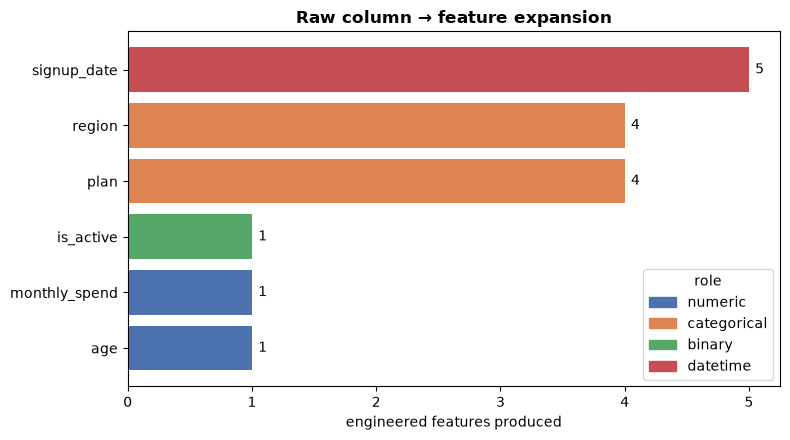

In [5]:
import matplotlib.pyplot as plt

# count engineered features produced by each kept source column
roles = {p.column: p.role for p in plan.plans}
src_counts = {}
for feat in features.columns:
    # match the longest source-column prefix
    src = max((col for col in roles if feat == col or feat.startswith(col + '_')),
              key=len, default=feat)
    src_counts[src] = src_counts.get(src, 0) + 1

order = sorted(src_counts, key=src_counts.get)
role_color = {'numeric': '#4C72B0', 'categorical': '#DD8452',
              'binary': '#55A868', 'datetime': '#C44E52'}
colors = [role_color.get(roles.get(s, ''), '#8172B3') for s in order]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(order, [src_counts[s] for s in order], color=colors)
ax.set_xlabel('engineered features produced')
ax.set_title('Raw column \u2192 feature expansion', fontweight='bold')
handles = [plt.Rectangle((0, 0), 1, 1, color=col) for col in role_color.values()]
ax.legend(handles, role_color.keys(), title='role', loc='lower right')
for i, s in enumerate(order):
    ax.text(src_counts[s] + 0.05, i, str(src_counts[s]), va='center')
plt.tight_layout()
plt.savefig('expansion.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary
| | |
|---|---|
| Raw columns in | 9 (with missing values, an id, free text) |
| Features out | 16 numeric, fully scaled/encoded |
| Missing values out | 0 |
| Leakage | none - stats fit on train, replayed on transform |
| Unseen categories | absorbed via `handle_unknown='ignore'` |

The `ColumnTransformer` is a plain sklearn object: drop it straight into a `Pipeline([...('model', clf)])`, `joblib.dump` it, and reuse the identical feature logic in training, batch scoring, and a live API.

## 🔧 Try your own
Uncomment and point at any CSV. Override an inferred role if you disagree with it.

In [6]:
# df = pd.read_csv('your_data.csv')
# plan = infer_plan(df, target='your_label_column')
#
# # override a role - e.g. force a numeric-looking zip code to be categorical:
# from factory import ColumnPlan, CATEGORICAL
# plan.plans = [ColumnPlan('zip', CATEGORICAL, 'manual') if p.column == 'zip' else p
#               for p in plan.plans]
#
# features, ct = fit_transform(df, plan)
# features.head()

---
Part of [phoebe-the-builder](https://github.com/phoebefu6/phoebe-the-builder) - Day 71, ML Engineering Toolkit.

**Streamlit version** (upload a CSV, edit the plan, download the feature matrix):
```bash
pip install -r requirements.txt
streamlit run app.py
```